<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 LD-PLSM Modeling and Comaprison with & without Environmental Parameters
</p>

In [79]:
import numpy as np                                           # For numerical operations
import pandas as pd                                          # For data manipulation and analysis
import matplotlib.pyplot as plt                              # For plotting and visualizations
import seaborn as sns                                        # For enhanced data visualizations
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import MaxNLocator                    # For controlling y-axis ticks
from sklearn.metrics import mean_squared_error, r2_score     # For model evaluation metrics
from sklearn.model_selection import KFold, train_test_split  # For splitting data and cross-validation
from sklearn.ensemble import HistGradientBoostingRegressor     # For quantile regression (fade-margin calibration)
from scipy.optimize import curve_fit                         # For curve fitting and optimization                       # For formula-based statistical modeling

In [80]:
# Define the path to the dataset
dataset_path = '../all_data_files/cleaned_dataset_per_device.csv'

# Load the dataset
try:
    df = pd.read_csv(dataset_path)
    print("\nDataset loaded successfully.\n")
except FileNotFoundError:
    print(f"File not found at the specified path: {dataset_path}")
    import sys
    sys.exit()


Dataset loaded successfully.



<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Data Preparation and Single Train-Test Split
</p>

In [81]:
# Extract the device_id column
device_id_all = df['device_id'].values

# Existing features and target
all_features = np.column_stack((
    df['distance'].values, 
    df['frequency'].values, 
    df['c_walls'].values, 
    df['w_walls'].values, 
    df['co2'].values, 
    df['humidity'].values,
    df['pm25'].values, 
    df['pressure'].values, 
    df['temperature'].values
))
PL_all = df['exp_pl'].values
time_all = df['time'].values
indices = np.arange(len(df))

# Use stratify to ensure the distribution of device IDs is preserved.
X_train_all, X_test_all, PL_train_all, PL_test_all, time_train, time_test, train_idx, test_idx = train_test_split(
    all_features,
    PL_all,
    time_all,
    indices,
    test_size=0.2,
    random_state=200,
    shuffle=True,
    stratify=device_id_all  # To ensure each device is represented in both splits.
)

# Sort the training set by time and overwrite the original variable names:
order_train = np.argsort(time_train)
time_train   = time_train[order_train]
X_train_all  = X_train_all[order_train]
PL_train_all = PL_train_all[order_train]
train_idx    = train_idx[order_train]

# Sort the test set by time and overwrite the original variable names:
order_test = np.argsort(time_test)
time_test   = time_test[order_test]
X_test_all  = X_test_all[order_test]
PL_test_all = PL_test_all[order_test]
test_idx    = test_idx[order_test]

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Analyzing Temporal Distribution in Training and Testing Sets
</p>

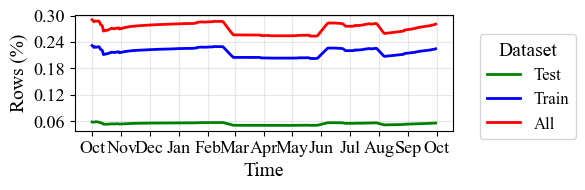

In [82]:
# Convert timestamp to datetime with explicit ISO8601 format
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Reuse the same train/test indices
train_indices = train_idx
test_indices  = test_idx

def calculate_percentage(indices, total_len, window=100):
    # Group by date using the 'time' column and count records
    daily_counts = df.iloc[indices].groupby(df.iloc[indices]['time'].dt.date).size()
    # Convert to percentage
    percentages = (daily_counts / total_len * 100).rename_axis('date')
    # Reindex to ensure continuity across dates and apply rolling mean
    full_range = pd.date_range(start=percentages.index.min(), end=percentages.index.max())
    return (percentages.reindex(full_range, fill_value=0)
                       .sort_index()
                       .rolling(window, min_periods=1)
                       .mean())

total_len = len(df)
train_percentages = calculate_percentage(train_indices, total_len)
test_percentages  = calculate_percentage(test_indices, total_len)
whole_percentages = calculate_percentage(indices, total_len)

fig, ax = plt.subplots(figsize=(6, 2))
ax.grid(True, alpha=0.3)

for data, color, label in [(test_percentages, 'green', 'Test'),
                           (train_percentages, 'blue', 'Train'),
                           (whole_percentages, 'red', 'All')]:
    ax.plot(data.index, data.values, color=color, label=label, linewidth=2)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Rows (%)', fontsize=14)

# Adjust the legend position to the right of the plot
ax.legend(title='Dataset', title_fontsize=14, fontsize=12,
          bbox_to_anchor=(1.05, 0.9), loc='upper left')

# Adjust x-axis formatting with year in front of the month
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b'))

ax.tick_params(axis='both', which='major', labelsize=13, direction='out')

# Adjust the y-axis ticks to include more scale values
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None)) 

plt.tight_layout()

# Save the figure to the specified directory with 1000 dpi
#plt.savefig('../all_data_files/Observations_Over_Time.png', dpi=1000)
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining LDPLM-MW Model, Fitting, and Extracting Parameters
</p>

In [83]:
# Indices for features used in LDPLM-MW
idx_mw = [0, 2, 3]  # Indices of d_all, c_walls_all, w_walls_all in all_features

# Extract training and testing data for LDPLM-MW
x_train_mw = X_train_all[:, idx_mw].T  # Transpose to match original shape
x_test_mw = X_test_all[:, idx_mw].T
PL_train_mw = PL_train_all
PL_test_mw = PL_test_all

# Define the Log-Distance Path Loss Model with Multi-Wall alone
def log_distance_path_loss_separate_walls(x, PL_d0, n, L_c, L_w):
    d, c_walls, w_walls = x
    d0 = 1  # Reference distance in meters
    return (PL_d0 + 10 * n * np.log10(d / d0) + c_walls * L_c + w_walls * L_w)

# Initial guesses for PL_d0, n, L_c, and L_w
initial_guesses_mw = [40, 3.5, 12, 5]  # Can be adjusted

# Perform curve fitting for LDPLM-MW
popt_mw, pcov_mw = curve_fit(
    log_distance_path_loss_separate_walls,
    x_train_mw,
    PL_train_mw,
    p0=initial_guesses_mw,
    maxfev=100000
)

# Extract the fitted parameters for LDPLM-MW
PL_d0_mw, n_mw, L_c_mw, L_w_mw = popt_mw

# Predict path loss for the test set
PL_pred_mw = log_distance_path_loss_separate_walls(x_test_mw, PL_d0_mw, n_mw, L_c_mw, L_w_mw)

# Calculate the shadowing component for the training set
PL_train_pred_mw = log_distance_path_loss_separate_walls(x_train_mw, PL_d0_mw, n_mw, L_c_mw, L_w_mw)
shadowing_train_mw = PL_train_mw - PL_train_pred_mw
sigma_mw = np.std(shadowing_train_mw)

# Calculate RMSE and R-squared for LDPLM-MW on Test Set
rmse_mw = np.sqrt(mean_squared_error(PL_test_mw, PL_pred_mw))
r_squared_mw = r2_score(PL_test_mw, PL_pred_mw)

# Calculate RMSE and R-squared for LDPLM-MW on Training Set
rmse_train_mw = np.sqrt(mean_squared_error(PL_train_mw, PL_train_pred_mw))
r_squared_train_mw = r2_score(PL_train_mw, PL_train_pred_mw)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining COST 231 MWM (Calibrated by Regression), Fitting, and Extracting Parameters
</p>

In [84]:
# Indices for features used in COST 231 MWM
idx_cost = [0, 1, 2, 3]  # Indices of d_all, frequency_all, c_walls_all, w_walls_all in all_features

# Extract training and testing data for COST 231 MWM
x_train_cost = X_train_all[:, idx_cost].T
x_test_cost = X_test_all[:, idx_cost].T
PL_train_cost = PL_train_all
PL_test_cost = PL_test_all

# Define the COST 231 Multi-Wall Model: free-space loss + constant loss + wall losses
# (one floor, so the COST 231 floor term is zero); calibrated by regression on the training set
def cost231_multi_wall(x, L_const, L_c, L_w):
    d, frequency, c_walls, w_walls = x
    L_FS = 20 * np.log10(4 * np.pi * d * frequency * 1e6 / 299792458)  # free-space loss, frequency in MHz
    return L_FS + L_const + c_walls * L_c + w_walls * L_w

# Initial guesses for L_const, L_c, and L_w (COST 231 values: 0 dB, heavy wall 6.9 dB, light wall 3.4 dB)
initial_guesses_cost = [0, 6.9, 3.4]

# Perform curve fitting for COST 231 MWM
popt_cost, pcov_cost = curve_fit(
    cost231_multi_wall,
    x_train_cost,
    PL_train_cost,
    p0=initial_guesses_cost,
    maxfev=100000
)

# Extract the fitted parameters for COST 231 MWM
L_const_cost, L_c_cost, L_w_cost = popt_cost

# Predict path loss for the test set
PL_pred_cost = cost231_multi_wall(x_test_cost, L_const_cost, L_c_cost, L_w_cost)

# Calculate the shadowing component for the training set
PL_train_pred_cost = cost231_multi_wall(x_train_cost, L_const_cost, L_c_cost, L_w_cost)
shadowing_train_cost = PL_train_cost - PL_train_pred_cost
sigma_cost = np.std(shadowing_train_cost)

# Calculate RMSE and R-squared for COST 231 MWM on Test Set
rmse_cost = np.sqrt(mean_squared_error(PL_test_cost, PL_pred_cost))
r_squared_cost = r2_score(PL_test_cost, PL_pred_cost)

# Calculate RMSE and R-squared for COST 231 MWM on Training Set
rmse_train_cost = np.sqrt(mean_squared_error(PL_train_cost, PL_train_pred_cost))
r_squared_train_cost = r2_score(PL_train_cost, PL_train_pred_cost)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining LDPLM-MW-EP Model, Fitting, and Extracting Parameters
</p>

In [85]:
# Indices for features used in LDPLM-MW-EP
idx_ep = [0, 1, 2, 3, 4, 5, 6, 7, 8]

# Extract training and testing data for LDPLM-MW-EP
x_train_ep = X_train_all[:, idx_ep].T
x_test_ep = X_test_all[:, idx_ep].T
PL_train_ep = PL_train_all
PL_test_ep = PL_test_all

# Define the enhanced Log-Distance Path Loss Model with Environmental Parameters
def log_distance_path_loss_with_env_params(x, PL_d0, n, L_c, L_w, a_co2, a_hum, a_pm25, a_pres, a_temp):
    d, frequency, c_walls, w_walls, co2, humidity, pm25, pressure, temperature = x
    d0 = 1  # Reference distance in meters
    return (PL_d0 + 10 * n * np.log10(d / d0) + 20 * np.log10(frequency) + c_walls * L_c + w_walls * L_w +
            a_co2 * co2 + a_hum * humidity + a_pm25 * pm25 +
            a_pres * pressure + a_temp * temperature)

# Initial guesses for PL_d0, n, L_c, L_w, and environmental factors
initial_guesses_ep = [40, 3.5, 12, 5, 0.0, 0.0, 0.0, 0.0, 0.0]  # Can be adjusted

# Perform curve fitting for LDPLM-MW-EP
popt_ep, pcov_ep = curve_fit(
    log_distance_path_loss_with_env_params,
    x_train_ep,
    PL_train_ep,
    p0=initial_guesses_ep,
    maxfev=100000
)

# Extract the fitted parameters for LDPLM-MW-EP
PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep = popt_ep

# Predict path loss for the test set
PL_pred_ep = log_distance_path_loss_with_env_params(
    x_test_ep, PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep
)

# Calculate the shadowing component for the training set
PL_train_pred_ep = log_distance_path_loss_with_env_params(
    x_train_ep, PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep
)
shadowing_train_ep = PL_train_ep - PL_train_pred_ep
sigma_ep = np.std(shadowing_train_ep)

# Calculate RMSE and R-squared for LDPLM-MW-EP on Test Set
rmse_ep = np.sqrt(mean_squared_error(PL_test_ep, PL_pred_ep))
r_squared_ep = r2_score(PL_test_ep, PL_pred_ep)

# Calculate RMSE and R-squared for LDPLM-MW-EP on Training Set
rmse_train_ep = np.sqrt(mean_squared_error(PL_train_ep, PL_train_pred_ep))
r_squared_train_ep = r2_score(PL_train_ep, PL_train_pred_ep)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Comparing Parameters and Metrics for the two Models
</p>

In [86]:
# Parameters Comparison
params_cost = {
    'Constant loss (L_const) [dB]': L_const_cost,
    'Path loss exponent (n)': 2,  # fixed by the free-space term
    'Brick Wall Loss (L_c) [dB]': L_c_cost,
    'Wood Wall Loss (L_w) [dB]': L_w_cost
}

params_mw = {
    'PL(d0) [dB]': PL_d0_mw,
    'Path loss exponent (n)': n_mw,
    'Brick Wall Loss (L_c) [dB]': L_c_mw,
    'Wood Wall Loss (L_w) [dB]': L_w_mw
}

params_ep = {
    'PL(d0) [dB]': PL_d0_ep,
    'Path loss exponent (n)': n_ep,
    'Brick Wall Loss (L_c) [dB]': L_c_ep,
    'Wood Wall Loss (L_w) [dB]': L_w_ep,
    'CO2 coefficient (a_co2) [dB/unit]': a_co2_ep,
    'Humidity coefficient (a_hum) [dB/unit]': a_hum_ep,
    'PM2.5 coefficient (a_pm25) [dB/unit]': a_pm25_ep,
    'Pressure coefficient (a_pres) [dB/unit]': a_pres_ep,
    'Temperature coefficient (a_temp) [dB/unit]': a_temp_ep
}

# Create the Parameter list: the constant loss of the COST 231 MWM + all LDPLM-MW-EP parameters
parameter_list = ['Constant loss (L_const) [dB]'] + list(params_ep)

# Construct the DataFrame: each model shows its own parameters and '-' for the others
params_df = pd.DataFrame({
    'Parameter': parameter_list,
    'COST 231 MWM': [params_cost.get(param, '-') for param in parameter_list],
    'LDPLM-MW': [params_mw.get(param, '-') for param in parameter_list],
    'LDPLM-MW-EP': [params_ep.get(param, '-') for param in parameter_list]
})

print("\n=== Table of Parameters to be Compared ===\n")
display(params_df)

# Metrics Comparison Including Training and Test Sets 
# Metrics Comparison
metrics = [
    'RMSE (Train) [dB]', 
    'RMSE (Test) [dB]', 
    'R-squared (Train)', 
    'R-squared (Test)', 
    'Shadowing σ (dB)'
]
metrics_values = {
    'COST 231 MWM': [rmse_train_cost, rmse_cost, r_squared_train_cost, r_squared_cost, sigma_cost],
    'LDPLM-MW': [rmse_train_mw, rmse_mw, r_squared_train_mw, r_squared_mw, sigma_mw],
    'LDPLM-MW-EP': [rmse_train_ep, rmse_ep, r_squared_train_ep, r_squared_ep, sigma_ep]
}

metrics_df = pd.DataFrame(metrics_values, index=metrics)

print("\n=== Performance Metrics Comparison ===\n")
display(metrics_df)

# Where the improvement comes from: one step at a time (test RMSE)
print("\n=== Gain of each modelling step (test RMSE) ===\n")
print(f"COST 231 MWM -> LDPLM-MW   (fitted distance exponent instead of free space): {rmse_cost - rmse_mw:.2f} dB")
print(f"LDPLM-MW -> LDPLM-MW-EP    (environmental parameters):                      {rmse_mw - rmse_ep:.2f} dB")


=== Table of Parameters to be Compared ===



,Parameter,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
0,Constant loss (L_const) [dB],13.225173,-,-
1,PL(d0) [dB],-,17.182673,-34.195488
2,Path loss exponent (n),2,4.894569,4.886532
3,Brick Wall Loss (L_c) [dB],10.772162,7.073322,7.180775
4,Wood Wall Loss (L_w) [dB],5.18353,1.141929,1.12679
5,CO2 coefficient (a_co2) [dB/unit],-,-,-0.002731
6,Humidity coefficient (a_hum) [dB/unit],-,-,-0.103613
7,PM2.5 coefficient (a_pm25) [dB/unit],-,-,-0.000619
8,Pressure coefficient (a_pres) [dB/unit],-,-,0.00139
9,Temperature coefficient (a_temp) [dB/unit],-,-,-0.143539



=== Performance Metrics Comparison ===



,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
RMSE (Train) [dB],6.949738,6.086127,6.031687
RMSE (Test) [dB],6.943841,6.078945,6.023392
R-squared (Train),0.839137,0.876632,0.878830
R-squared (Test),0.839233,0.876788,0.879030
Shadowing σ (dB),6.949738,6.086127,6.031687



=== Gain of each modelling step (test RMSE) ===

COST 231 MWM -> LDPLM-MW   (fitted distance exponent instead of free space): 0.86 dB
LDPLM-MW -> LDPLM-MW-EP    (environmental parameters):                      0.06 dB


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plotting some comparison Parameters and Metrics for the two Models
</p>

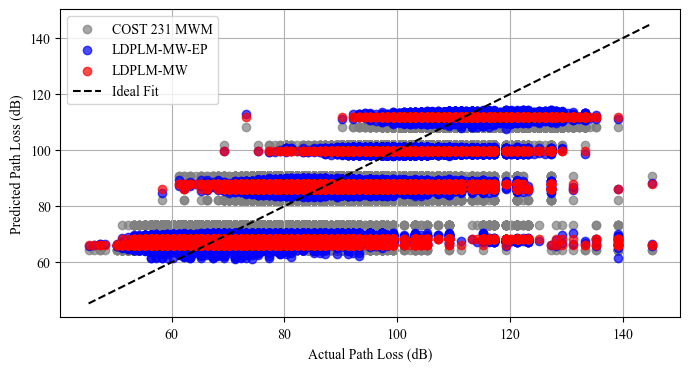

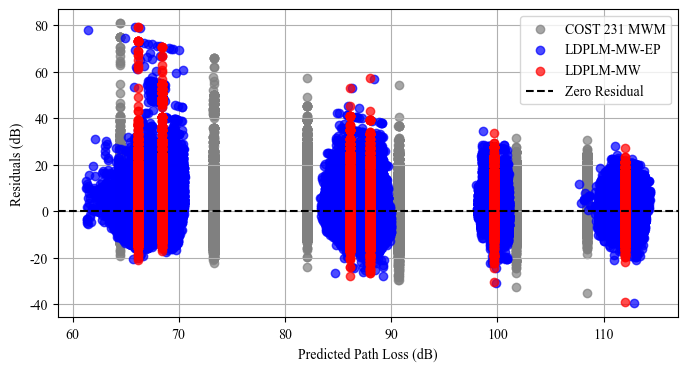

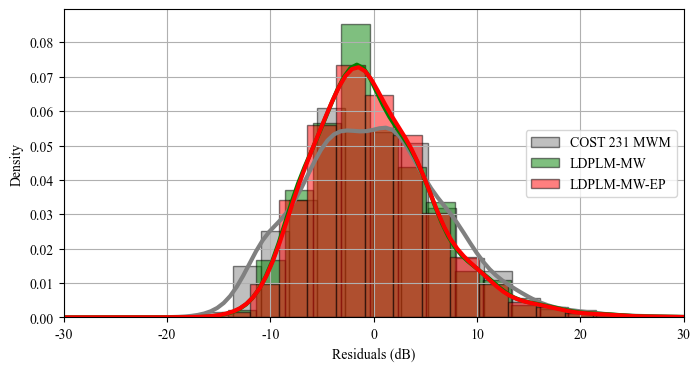


Residual Distribution Values:

COST 231 MWM: Mean: 0.0132 dB, Skewness: 0.5675
LDPLM-MW: Mean: 0.0132 dB, Skewness: 1.0233
LDPLM-MW-EP: Mean: 0.0123 dB, Skewness: 0.9901


In [87]:
# -------------------------------
# Section 4: 
# -------------------------------

# Step 15: Plot Actual vs Predicted Path Loss
plt.figure(figsize=(8, 4))
# Plot COST 231 MWM at the back in gray
plt.scatter(PL_test_cost, PL_pred_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP first in blue
plt.scatter(PL_test_ep, PL_pred_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW last in red to appear in foreground
plt.scatter(PL_test_mw, PL_pred_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Ideal Fit Line in black, highest zorder to appear on top
min_PL = min(PL_test_mw.min(), PL_test_ep.min(), PL_pred_mw.min(), PL_pred_ep.min(), PL_pred_cost.min())
max_PL = max(PL_test_mw.max(), PL_test_ep.max(), PL_pred_mw.max(), PL_pred_ep.max(), PL_pred_cost.max())
plt.plot(
    [min_PL, max_PL],
    [min_PL, max_PL],
    'k--', label='Ideal Fit', zorder=4
)
plt.xlabel('Actual Path Loss (dB)')
plt.ylabel('Predicted Path Loss (dB)')
# plt.title('Actual vs Predicted Path Loss Comparison')
plt.legend(loc='upper left')
plt.grid(True)
#plt.savefig('../all_data_files/Actual_vs_Predicted.png', dpi=1000)
plt.show()

# Step 16: Residual Analysis - Residuals vs Predicted Path Loss
residuals_mw = PL_test_mw - PL_pred_mw
residuals_ep = PL_test_ep - PL_pred_ep
residuals_cost = PL_test_cost - PL_pred_cost

plt.figure(figsize=(8, 4))
# Plot COST 231 MWM residuals at the back in gray
plt.scatter(PL_pred_cost, residuals_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP residuals first in blue
plt.scatter(PL_pred_ep, residuals_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW residuals last in red to appear in foreground
plt.scatter(PL_pred_mw, residuals_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Horizontal line at zero in black, highest zorder to appear on top
plt.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4)
plt.xlabel('Predicted Path Loss (dB)')
plt.ylabel('Residuals (dB)')
# plt.title('Residuals vs Predicted Path Loss Comparison')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('../all_data_files/Residuals_vs_Predicted.png', dpi=1000)
plt.show()

# Step 17: Residual Analysis - Histogram of Residuals with KDE and Smoothness Control
plt.figure(figsize=(8, 4))

# Plot histograms with density=True to normalize the counts
plt.hist(residuals_cost, bins=43, alpha=0.5, label='COST 231 MWM', color='gray', edgecolor='k', density=True)
plt.hist(residuals_mw, bins=43, alpha=0.5, label='LDPLM-MW', color='green', edgecolor='k', density=True)
plt.hist(residuals_ep, bins=43, alpha=0.5, label='LDPLM-MW-EP', color='red', edgecolor='k', density=True)

# KDE plots using Seaborn 
sns.kdeplot(residuals_cost, color='gray', bw_adjust=3, linewidth=3)
sns.kdeplot(residuals_mw, color='green', bw_adjust=3, linewidth=3)
sns.kdeplot(residuals_ep, color='red', bw_adjust=3, linewidth=3)

plt.xlabel('Residuals (dB)')
plt.ylabel('Density')  # Changed from 'Frequency' to 'Density' due to normalization
# plt.title('Histogram of Residuals Comparison')
plt.xlim(-30, 30)  # Set x-axis limits
plt.legend(loc='center right')
plt.grid(True)
#plt.savefig('../all_data_files/Histogram_of_Residuals_with_KDE.png', dpi=1000)
plt.show()

# Convert numpy arrays to pandas Series
residuals_mw = pd.Series(residuals_mw)
residuals_ep = pd.Series(residuals_ep)
residuals_cost = pd.Series(residuals_cost)

# Residual Distribution Values
resid_mean_mw = round(residuals_mw.mean(), 4)
resid_skew_mw = round(residuals_mw.skew(), 4)

resid_mean_ep = round(residuals_ep.mean(), 4)
resid_skew_ep = round(residuals_ep.skew(), 4)

resid_mean_cost = round(residuals_cost.mean(), 4)
resid_skew_cost = round(residuals_cost.skew(), 4)

print(f'\nResidual Distribution Values:')
print(f'\nCOST 231 MWM: Mean: {resid_mean_cost} dB, Skewness: {resid_skew_cost}')
print(f'LDPLM-MW: Mean: {resid_mean_mw} dB, Skewness: {resid_skew_mw}')
print(f'LDPLM-MW-EP: Mean: {resid_mean_ep} dB, Skewness: {resid_skew_ep}')

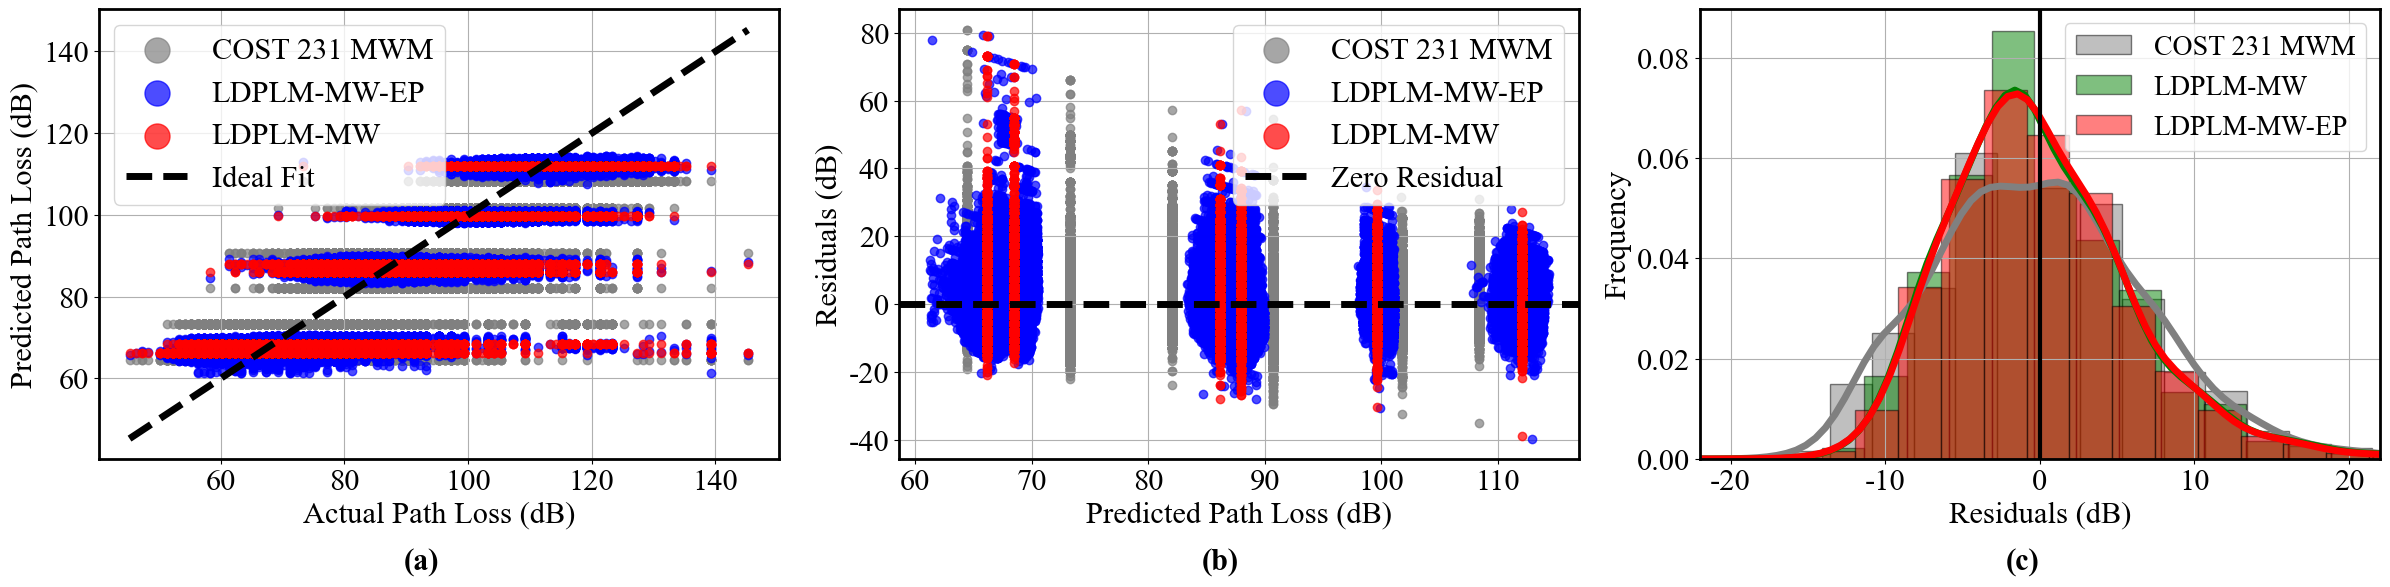


Residual Distribution Values:

COST 231 MWM: Mean: 0.0132 dB, Skewness: 0.5675
LDPLM-MW: Mean: 0.0132 dB, Skewness: 1.0233
LDPLM-MW-EP: Mean: 0.0123 dB, Skewness: 0.9901


In [88]:
# -------------------------------
# Section 4: Plotting (Re-arranging the plots for the manuscript)
# -------------------------------

# Step 15, 16 & 17: Plot Actual vs Predicted Path Loss, Residual Analysis, and Histogram as Subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Step 15: Plot Actual vs Predicted Path Loss on ax1
# Plot COST 231 MWM at the back in gray
ax1.scatter(PL_test_cost, PL_pred_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP first in blue
ax1.scatter(PL_test_ep, PL_pred_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW last in red to appear in foreground
ax1.scatter(PL_test_mw, PL_pred_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Ideal Fit Line in black, highest zorder to appear on top
ax1.plot(
    [min_PL, max_PL],
    [min_PL, max_PL],
    'k--', label='Ideal Fit', zorder=4, linewidth=5
)
ax1.set_xlabel('Actual Path Loss (dB)', fontsize=22)
ax1.set_ylabel('Predicted Path Loss (dB)', fontsize=22)
# ax1.set_title('Actual vs Predicted Path Loss Comparison')
ax1.legend(fontsize=22, loc='upper left', markerscale=3)
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=22)
ax1.text(0.5, -0.2, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Step 16: Residual Analysis - Residuals vs Predicted Path Loss on ax2
# Plot COST 231 MWM residuals at the back in gray
ax2.scatter(PL_pred_cost, residuals_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP residuals first in blue
ax2.scatter(PL_pred_ep, residuals_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW residuals last in red to appear in foreground
ax2.scatter(PL_pred_mw, residuals_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Zero Residual Line in black, highest zorder to appear on top
ax2.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4, linewidth=5)
ax2.set_xlabel('Predicted Path Loss (dB)', fontsize=22)
ax2.set_ylabel('Residuals (dB)', fontsize=22)
# ax2.set_title('Residuals vs Predicted Path Loss Comparison')
ax2.legend(fontsize=22, loc='upper right', markerscale=3)
ax2.grid(True)
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.text(0.5, -0.2, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Step 17: Residual Analysis - Histogram of Residuals on ax3
# Plot histogram for COST 231 MWM
ax3.hist(residuals_cost, bins=43, alpha=0.5, label='COST 231 MWM', color='gray', edgecolor='k', density=True)
# Plot histogram for LDPLM-MW
ax3.hist(residuals_mw, bins=43, alpha=0.5, label='LDPLM-MW', color='green', edgecolor='k', density=True)
# Plot histogram for LDPLM-MW-EP with density normalization
ax3.hist(residuals_ep, bins=43, alpha=0.5, label='LDPLM-MW-EP', color='red', edgecolor='k', density=True)
# KDE plots using Seaborn 
sns.kdeplot(residuals_cost, color='gray', bw_adjust=3, ax=ax3, linewidth=5)
sns.kdeplot(residuals_mw, color='green', bw_adjust=3, ax=ax3, linewidth=5)
sns.kdeplot(residuals_ep, color='red', bw_adjust=3, ax=ax3, linewidth=5)

ax3.axvline(0, color='black', linestyle='-', linewidth=3)
ax3.set_xlabel('Residuals (dB)', fontsize=22)
ax3.set_ylabel('Frequency', fontsize=22)
# ax3.set_title('Histogram of Residuals Comparison')
ax3.set_xlim(-22, 22)  # Set x-axis limits
ax3.legend(fontsize=20, loc='upper right')
ax3.grid(True)
ax3.tick_params(axis='both', which='major', labelsize=22)
ax3.text(0.5, -0.2, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Save the combined figure
#plt.savefig('../all_data_files/All_Plots_as_Subplots.png', dpi=1000)
plt.show()

# Residual Distribution Values
resid_mean_mw = round(residuals_mw.mean(), 4)
resid_skew_mw = round(residuals_mw.skew(), 4)

resid_mean_ep = round(residuals_ep.mean(), 4)
resid_skew_ep = round(residuals_ep.skew(), 4)

resid_mean_cost = round(residuals_cost.mean(), 4)
resid_skew_cost = round(residuals_cost.skew(), 4)

print(f'\nResidual Distribution Values:')
print(f'\nCOST 231 MWM: Mean: {resid_mean_cost} dB, Skewness: {resid_skew_cost}')
print(f'LDPLM-MW: Mean: {resid_mean_mw} dB, Skewness: {resid_skew_mw}')
print(f'LDPLM-MW-EP: Mean: {resid_mean_ep} dB, Skewness: {resid_skew_ep}')

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Cross-Validation
</p>

In [89]:
# -------------------------------
# Section 5: Cross-Validation
# -------------------------------

X_all = all_features 
kf = KFold(n_splits=5, shuffle=True, random_state=50)

# Define idx_ep to include all relevant feature indices
idx_ep = [0, 1, 2, 3, 4, 5, 6, 7, 8]  

# Initialize lists to store metrics
rmse_list_mw_train = []
r_squared_list_mw_train = []
rmse_list_mw_test = []
r_squared_list_mw_test = []

rmse_list_ep_train = []
r_squared_list_ep_train = []
rmse_list_ep_test = []
r_squared_list_ep_test = []

rmse_list_cost_train = []
r_squared_list_cost_train = []
rmse_list_cost_test = []
r_squared_list_cost_test = []

fold_metrics = []  # To store metrics for each fold

for fold, (train_index, test_index) in enumerate(kf.split(df), 1):
    # Extract training and testing data for COST 231 MWM
    x_train_cv_cost = X_all[train_index][:, idx_cost].T
    x_test_cv_cost = X_all[test_index][:, idx_cost].T
    PL_train_cv_cost = PL_all[train_index]
    PL_test_cv_cost = PL_all[test_index]
    
    try:
        popt_cv_cost, _ = curve_fit(
            cost231_multi_wall,
            x_train_cv_cost,
            PL_train_cv_cost,
            p0=initial_guesses_cost,
            maxfev=100000
        )
        
        L_const_cv_cost, L_c_cv_cost, L_w_cv_cost = popt_cv_cost
        
        PL_pred_cv_cost = cost231_multi_wall(
            x_test_cv_cost, L_const_cv_cost, L_c_cv_cost, L_w_cv_cost
        )
        
        # Calculate RMSE and R-squared on Test Set for COST 231 MWM
        rmse_cv_cost_test = np.sqrt(mean_squared_error(PL_test_cv_cost, PL_pred_cv_cost))
        r2_cv_cost_test = r2_score(PL_test_cv_cost, PL_pred_cv_cost)
        
        # Calculate RMSE and R-squared on Training Set for COST 231 MWM
        PL_train_pred_cv_cost = cost231_multi_wall(
            x_train_cv_cost, L_const_cv_cost, L_c_cv_cost, L_w_cv_cost
        )
        rmse_cv_cost_train = np.sqrt(mean_squared_error(PL_train_cv_cost, PL_train_pred_cv_cost))
        r2_cv_cost_train = r2_score(PL_train_cv_cost, PL_train_pred_cv_cost)
        
        rmse_list_cost_test.append(rmse_cv_cost_test)
        r_squared_list_cost_test.append(r2_cv_cost_test)
        rmse_list_cost_train.append(rmse_cv_cost_train)
        r_squared_list_cost_train.append(r2_cv_cost_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for COST 231 MWM Fold {fold}.")
        rmse_list_cost_test.append(np.nan)
        r_squared_list_cost_test.append(np.nan)
        rmse_list_cost_train.append(np.nan)
        r_squared_list_cost_train.append(np.nan)
    
    # Extract training and testing data for LDPLM-MW
    x_train_cv_mw = X_all[train_index][:, idx_mw].T  # Transpose to match original shape
    x_test_cv_mw = X_all[test_index][:, idx_mw].T
    PL_train_cv_mw = PL_all[train_index]
    PL_test_cv_mw = PL_all[test_index]
    
    try:
        popt_cv_mw, _ = curve_fit(
            log_distance_path_loss_separate_walls,
            x_train_cv_mw,
            PL_train_cv_mw,
            p0=initial_guesses_mw,
            maxfev=100000
        )
        
        PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw = popt_cv_mw
        
        PL_pred_cv_mw = log_distance_path_loss_separate_walls(
            x_test_cv_mw, PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw
        )
        
        # Calculate RMSE and R-squared on Test Set for LDPLM-MW
        rmse_cv_mw_test = np.sqrt(mean_squared_error(PL_test_cv_mw, PL_pred_cv_mw))
        r2_cv_mw_test = r2_score(PL_test_cv_mw, PL_pred_cv_mw)
        
        # Calculate RMSE and R-squared on Training Set for LDPLM-MW 
        PL_train_pred_cv_mw = log_distance_path_loss_separate_walls(
            x_train_cv_mw, PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw
        )
        rmse_cv_mw_train = np.sqrt(mean_squared_error(PL_train_cv_mw, PL_train_pred_cv_mw))
        r2_cv_mw_train = r2_score(PL_train_cv_mw, PL_train_pred_cv_mw)
        
        rmse_list_mw_test.append(rmse_cv_mw_test)
        r_squared_list_mw_test.append(r2_cv_mw_test)
        rmse_list_mw_train.append(rmse_cv_mw_train)
        r_squared_list_mw_train.append(r2_cv_mw_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for LDPLM-MW Fold {fold}.")
        rmse_list_mw_test.append(np.nan)
        r_squared_list_mw_test.append(np.nan)
        rmse_list_mw_train.append(np.nan)
        r_squared_list_mw_train.append(np.nan)
    
    # Extract training and testing data for LDPLM-MW-EP
    x_train_cv_ep = X_all[train_index][:, idx_ep].T  # Transpose to match original shape
    x_test_cv_ep = X_all[test_index][:, idx_ep].T
    PL_train_cv_ep = PL_all[train_index]
    PL_test_cv_ep = PL_all[test_index]
    
    try:
        popt_cv_ep, _ = curve_fit(
            log_distance_path_loss_with_env_params,
            x_train_cv_ep,
            PL_train_cv_ep,
            p0=initial_guesses_ep,
            maxfev=100000
        )
        
        (PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep, a_co2_cv_ep, 
         a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep) = popt_cv_ep
        
        PL_pred_cv_ep = log_distance_path_loss_with_env_params(
            x_test_cv_ep, PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep,
            a_co2_cv_ep, a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep
        )
        
        # Calculate RMSE and R-squared on Test Set for LDPLM-MW-EP
        rmse_cv_ep_test = np.sqrt(mean_squared_error(PL_test_cv_ep, PL_pred_cv_ep))
        r2_cv_ep_test = r2_score(PL_test_cv_ep, PL_pred_cv_ep)
        
        # Calculate RMSE and R-squared on Training Set for LDPLM-MW-EP 
        PL_train_pred_cv_ep = log_distance_path_loss_with_env_params(
            x_train_cv_ep, PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep,
            a_co2_cv_ep, a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep
        )
        rmse_cv_ep_train = np.sqrt(mean_squared_error(PL_train_cv_ep, PL_train_pred_cv_ep))
        r2_cv_ep_train = r2_score(PL_train_cv_ep, PL_train_pred_cv_ep)
        
        rmse_list_ep_test.append(rmse_cv_ep_test)
        r_squared_list_ep_test.append(r2_cv_ep_test)
        rmse_list_ep_train.append(rmse_cv_ep_train)
        r_squared_list_ep_train.append(r2_cv_ep_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for LDPLM-MW-EP Fold {fold}.")
        rmse_list_ep_test.append(np.nan)
        r_squared_list_ep_test.append(np.nan)
        rmse_list_ep_train.append(np.nan)
        r_squared_list_ep_train.append(np.nan)
    
    fold_metrics.append({
        'Fold': fold,
        'COST 231 MWM RMSE Train (dB)': rmse_cv_cost_train,
        'COST 231 MWM R² Train': r2_cv_cost_train,
        'COST 231 MWM RMSE Test (dB)': rmse_cv_cost_test,
        'COST 231 MWM R² Test': r2_cv_cost_test,
        'LDPLM-MW RMSE Train (dB)': rmse_cv_mw_train,
        'LDPLM-MW R² Train': r2_cv_mw_train,
        'LDPLM-MW RMSE Test (dB)': rmse_cv_mw_test,
        'LDPLM-MW R² Test': r2_cv_mw_test,
        'LDPLM-MW-EP RMSE Train (dB)': rmse_cv_ep_train,
        'LDPLM-MW-EP R² Train': r2_cv_ep_train,
        'LDPLM-MW-EP RMSE Test (dB)': rmse_cv_ep_test,
        'LDPLM-MW-EP R² Test': r2_cv_ep_test
    })

# Create Fold-wise Metrics Table
fold_df = pd.DataFrame(fold_metrics)
fold_df.set_index('Fold', inplace=True)
fold_df = fold_df.rename_axis(index='Fold')

# Reorganize columns for better comparison
fold_df = fold_df[[
    'COST 231 MWM RMSE Train (dB)', 'COST 231 MWM R² Train',
    'LDPLM-MW RMSE Train (dB)', 'LDPLM-MW R² Train',
    'LDPLM-MW-EP RMSE Train (dB)', 'LDPLM-MW-EP R² Train',
    'COST 231 MWM RMSE Test (dB)', 'COST 231 MWM R² Test',
    'LDPLM-MW RMSE Test (dB)', 'LDPLM-MW R² Test',
    'LDPLM-MW-EP RMSE Test (dB)', 'LDPLM-MW-EP R² Test'
]]

# Display Fold-wise Metrics Table
print("=== Fold-wise Metrics ===")
display(fold_df)

# Calculate and Prepare the Average and Standard Deviation of Metrics
avg_rmse_cost_train = np.nanmean(rmse_list_cost_train)
std_rmse_cost_train = np.nanstd(rmse_list_cost_train)

avg_r2_cost_train = np.nanmean(r_squared_list_cost_train)
std_r2_cost_train = np.nanstd(r_squared_list_cost_train)

avg_rmse_cost_test = np.nanmean(rmse_list_cost_test)
std_rmse_cost_test = np.nanstd(rmse_list_cost_test)

avg_r2_cost_test = np.nanmean(r_squared_list_cost_test)
std_r2_cost_test = np.nanstd(r_squared_list_cost_test)

avg_rmse_mw_train = np.nanmean(rmse_list_mw_train)
std_rmse_mw_train = np.nanstd(rmse_list_mw_train)

avg_r2_mw_train = np.nanmean(r_squared_list_mw_train)
std_r2_mw_train = np.nanstd(r_squared_list_mw_train)

avg_rmse_mw_test = np.nanmean(rmse_list_mw_test)
std_rmse_mw_test = np.nanstd(rmse_list_mw_test)

avg_r2_mw_test = np.nanmean(r_squared_list_mw_test)
std_r2_mw_test = np.nanstd(r_squared_list_mw_test)

avg_rmse_ep_train = np.nanmean(rmse_list_ep_train)
std_rmse_ep_train = np.nanstd(rmse_list_ep_train)

avg_r2_ep_train = np.nanmean(r_squared_list_ep_train)
std_r2_ep_train = np.nanstd(r_squared_list_ep_train)

avg_rmse_ep_test = np.nanmean(rmse_list_ep_test)
std_rmse_ep_test = np.nanstd(rmse_list_ep_test)

avg_r2_ep_test = np.nanmean(r_squared_list_ep_test)
std_r2_ep_test = np.nanstd(r_squared_list_ep_test)

# Create Average Metrics Table
average_metrics = {
    'COST 231 MWM': {
        'RMSE Train (dB)': f"{avg_rmse_cost_train:.4f} ± {std_rmse_cost_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_cost_test:.4f} ± {std_rmse_cost_test:.4f}",
        'R² Train': f"{avg_r2_cost_train:.4f} ± {std_r2_cost_train:.4f}",
        'R² Test': f"{avg_r2_cost_test:.4f} ± {std_r2_cost_test:.4f}"
    },
    'LDPLM-MW': {
        'RMSE Train (dB)': f"{avg_rmse_mw_train:.4f} ± {std_rmse_mw_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_mw_test:.4f} ± {std_rmse_mw_test:.4f}",
        'R² Train': f"{avg_r2_mw_train:.4f} ± {std_r2_mw_train:.4f}",
        'R² Test': f"{avg_r2_mw_test:.4f} ± {std_r2_mw_test:.4f}"
    },
    'LDPLM-MW-EP': {
        'RMSE Train (dB)': f"{avg_rmse_ep_train:.4f} ± {std_rmse_ep_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_ep_test:.4f} ± {std_rmse_ep_test:.4f}",
        'R² Train': f"{avg_r2_ep_train:.4f} ± {std_r2_ep_train:.4f}",
        'R² Test': f"{avg_r2_ep_test:.4f} ± {std_r2_ep_test:.4f}"
    }
}

# Convert the average_metrics dictionary to a DataFrame
average_df = pd.DataFrame(average_metrics)

# Display Average Metrics Table
print("\n=== Average Metrics Across Folds ===")
display(average_df)

=== Fold-wise Metrics ===


,COST 231 MWM RMSE Train (dB),COST 231 MWM R² Train,LDPLM-MW RMSE Train (dB),LDPLM-MW R² Train,LDPLM-MW-EP RMSE Train (dB),LDPLM-MW-EP R² Train,COST 231 MWM RMSE Test (dB),COST 231 MWM R² Test,LDPLM-MW RMSE Test (dB),LDPLM-MW R² Test,LDPLM-MW-EP RMSE Test (dB),LDPLM-MW-EP R² Test
Fold,,,,,,,,,,,,
1,6.948942,0.839176,6.086288,0.876628,6.031535,0.878837,6.947025,0.839077,6.078299,0.876807,6.023993,0.878999
2,6.948077,0.839136,6.083192,0.876692,6.028923,0.878882,6.950486,0.839235,6.090685,0.876549,6.034444,0.878819
3,6.949644,0.839099,6.083836,0.876693,6.029210,0.878897,6.944215,0.839383,6.088115,0.876545,6.033307,0.878757
4,6.947652,0.839218,6.084447,0.876689,6.029908,0.878889,6.952183,0.838909,6.085667,0.876563,6.030507,0.878791
5,6.948475,0.839152,6.085683,0.876617,6.030541,0.878842,6.948896,0.839175,6.080722,0.876850,6.027976,0.878978



=== Average Metrics Across Folds ===


,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
RMSE Train (dB),6.9486 ± 0.0007,6.0847 ± 0.0011,6.0300 ± 0.0009
RMSE Test (dB),6.9486 ± 0.0028,6.0847 ± 0.0046,6.0300 ± 0.0038
R² Train,0.8392 ± 0.0000,0.8767 ± 0.0000,0.8789 ± 0.0000
R² Test,0.8392 ± 0.0002,0.8767 ± 0.0001,0.8789 ± 0.0001


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Where the Environmental Parameters Matter: Presence Widens the Fluctuations, Not the Mean
</p>

The environmental parameters add almost nothing to the mean path loss (previous table), but they mark when people are in the office. To see what presence does, the slow drift is removed first: each packet's path loss is compared with the same link's mean over the previous 24 hours, which leaves the short-term fluctuation. Working-day daytime is then compared with daytime on public holidays, the only days on which the clock says "working hours" while the office is empty, and with weekends and nights. If presence mattered, the fluctuation on holidays would look like a weekend, not like a working day. The last table splits working hours by whether the building's CO$_2$ is more than 100 ppm above its daily floor, which is what the sensors can add beyond the clock.

In [90]:
# Path loss relative to each link's own previous-24-hour mean: slow drift removed, short-term fluctuation kept
presence = df[['time', 'device_id', 'exp_pl', 'co2', 'humidity', 'pm25', 'pressure', 'temperature']].sort_values(['device_id', 'time']).copy()
baseline, co2_excess = [], []
for _, link in presence.groupby('device_id'):
    s = link.set_index('time')
    baseline.append(pd.Series(s['exp_pl'].rolling('24h', closed='left').mean().values, index=link.index))
    co2_excess.append(pd.Series((s['co2'] - s['co2'].rolling('24h').min()).values, index=link.index))
presence['deviation'] = presence['exp_pl'] - pd.concat(baseline)
presence['co2_excess'] = pd.concat(co2_excess)  # CO2 above its own 24 h floor, ppm
presence = presence.dropna(subset=['deviation'])  # first 24 h of each link has no baseline

# Local time, and the day types: NRW public holidays on weekdays, the Christmas closure week, weekends, nights
local = presence['time'].dt.tz_convert('Europe/Berlin')
presence['day'] = local.dt.strftime('%Y-%m-%d')
daytime = (local.dt.hour >= 8) & (local.dt.hour < 18)
weekday = local.dt.dayofweek < 5
holidays = {'2024-10-03', '2024-11-01', '2024-12-25', '2024-12-26', '2025-01-01', '2025-04-18', '2025-04-21', '2025-05-01', '2025-05-29', '2025-06-09', '2025-06-19'}
christmas_week = {'2024-12-23', '2024-12-24', '2024-12-27', '2024-12-30', '2024-12-31', '2025-01-02', '2025-01-03'}
day_types = ['08-18 normal weekday', '08-18 public holiday (weekday)', '08-18 Christmas-week weekday', '08-18 weekend', '22-06 night']
presence['day_type'] = np.select(
    [daytime & presence['day'].isin(holidays), daytime & presence['day'].isin(christmas_week), daytime & weekday, daytime & ~weekday, (local.dt.hour >= 22) | (local.dt.hour < 6)],
    [day_types[1], day_types[2], day_types[0], day_types[3], day_types[4]], default='other')
presence['working_hours'] = daytime & weekday

by_day_type = presence[presence['day_type'] != 'other'].groupby('day_type').agg(
    days=('day', 'nunique'), rows=('deviation', 'size'), co2_excess_ppm=('co2_excess', 'mean'),
    spread_std_dB=('deviation', 'std'), q99_dB=('deviation', lambda s: s.quantile(0.99))).loc[day_types]
print("\n=== Path loss around the link's previous-24-hour mean, by day type (all links) ===\n")
display(by_day_type.round(2))
print("Spread (std, dB) per link:")
display(presence[presence['day_type'] != 'other'].groupby(['device_id', 'day_type'])['deviation'].std().unstack()[day_types].round(2))

# Bootstrap over days: spread on normal weekdays minus spread on public holidays
by_day = presence[presence['day_type'].isin(day_types[:2])].groupby(['day_type', 'day'])['deviation'].agg(sum_sq=lambda s: (s ** 2).sum(), n='size')
spread = lambda x: np.sqrt(x['sum_sq'].sum() / x['n'].sum())
normal, holiday = by_day.loc[day_types[0]], by_day.loc[day_types[1]]
rng = np.random.default_rng(1)
diffs = [spread(normal.sample(len(normal), replace=True, random_state=rng)) - spread(holiday.sample(len(holiday), replace=True, random_state=rng)) for _ in range(2000)]
print(f"Normal weekday minus public holiday, 08-18 h spread: {spread(normal) - spread(holiday):.2f} dB, "
      f"95% CI [{np.percentile(diffs, 2.5):.2f}, {np.percentile(diffs, 97.5):.2f}] (bootstrap over days)")

# Working hours (Mon-Fri 08-18) against the rest: the level barely moves, the spread widens
by_clock = presence.groupby(['device_id', 'working_hours']).agg(
    co2_ppm=('co2', 'mean'), PL_mean_dB=('exp_pl', 'mean'), spread_std_dB=('deviation', 'std'),
    q99_dB=('deviation', lambda s: s.quantile(0.99))).round(2).unstack()
print("\n=== Working hours (True) against off-hours (False), per link ===\n")
display(by_clock)

# Within working hours: is the building's CO2 more than 100 ppm above its daily floor (people present) or not?
presence['hour'] = presence['time'].dt.floor('h')
building_co2_excess = presence.groupby(['hour', 'device_id'])['co2_excess'].mean().unstack().mean(axis=1)
presence['co2_occupied'] = presence['hour'].map(building_co2_excess) > 100
by_clock_and_co2 = presence.groupby(['working_hours', 'co2_occupied'])['deviation'].agg(
    share_pct=lambda s: 100 * len(s) / len(presence), spread_std_dB='std', q99_dB=lambda s: s.quantile(0.99)).round(2)
print("\n=== Clock state and CO2 state together (all links) ===\n")
display(by_clock_and_co2)


=== Path loss around the link's previous-24-hour mean, by day type (all links) ===



,days,rows,co2_excess_ppm,spread_std_dB,q99_dB
day_type,,,,,
08-18 normal weekday,230,723606,134.45,4.70,14.23
08-18 public holiday (weekday),11,35067,23.02,3.23,10.36
08-18 Christmas-week weekday,7,22618,25.18,3.43,10.26
08-18 weekend,100,322774,21.13,3.27,9.65
22-06 night,349,889597,52.51,3.50,10.62


Spread (std, dB) per link:


day_type,08-18 normal weekday,08-18 public holiday (weekday),08-18 Christmas-week weekday,08-18 weekend,22-06 night
device_id,,,,,
ED0,4.23,3.17,3.97,3.22,3.38
ED1,4.71,3.22,3.27,3.96,3.71
ED2,5.41,3.38,3.30,3.20,3.69
ED3,4.23,3.47,3.25,3.36,3.53
ED4,4.11,3.09,3.35,2.94,3.11
ED5,4.99,3.01,3.37,2.82,3.44


Normal weekday minus public holiday, 08-18 h spread: 1.46 dB, 95% CI [1.31, 1.63] (bootstrap over days)

=== Working hours (True) against off-hours (False), per link ===



co2_ppm         PL_mean_dB         spread_std_dB       q99_dB  \
working_hours   False   True       False   True          False True   False   
device_id                                                                     
ED0            510.28  596.72      65.37   65.25          3.45  4.19  10.15   
ED1            498.46  564.30      70.70   70.52          3.86  4.62  10.88   
ED2            495.74  594.37      86.66   86.59          3.73  5.28  11.96   
ED3            499.47  621.85      84.34   84.97          3.55  4.17  11.32   
ED4            490.20  507.46     100.31  101.17          3.13  4.05   9.02   
ED5            463.58  572.80     113.33  110.98          3.48  4.91  10.98   

                      
working_hours  True   
device_id             
ED0            13.60  
ED1            13.45  
ED2            16.94  
ED3            14.35  
ED4            13.80  
ED5            11.98


=== Clock state and CO2 state together (all links) ===



share_pct  spread_std_dB  q99_dB
working_hours co2_occupied                                  
False         False             59.81           3.46   10.43
              True              10.82           4.02   12.35
True          False             15.80           4.31   13.17
              True              13.57           4.93   14.95

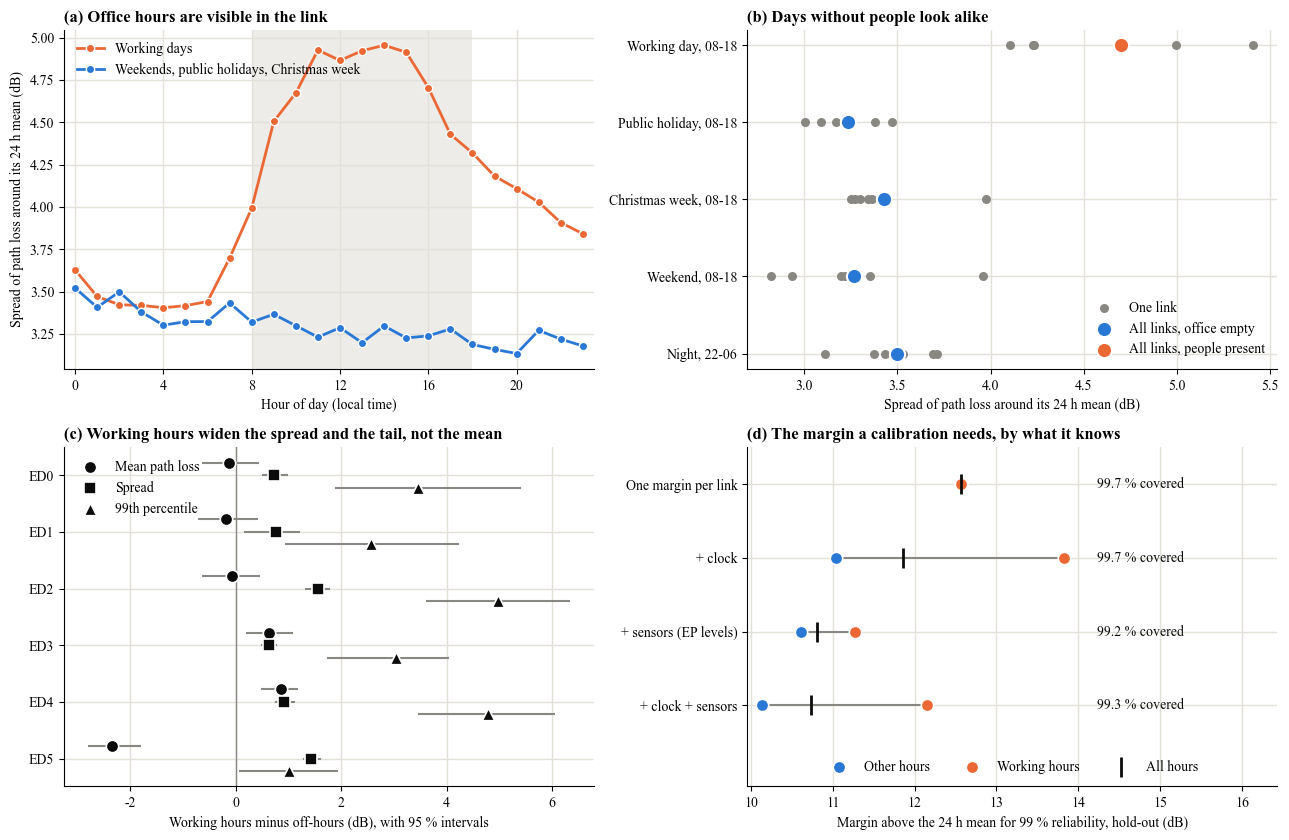


=== Working hours minus off-hours per link: estimate [95 % interval], dB ===



,Mean path loss,Spread,99th percentile
ED0,"-0.13 [-0.64, +0.43]","+0.73 [+0.49, +0.98]","+3.46 [+1.87, +5.42]"
ED1,"-0.18 [-0.71, +0.42]","+0.76 [+0.15, +1.22]","+2.57 [+0.94, +4.24]"
ED2,"-0.07 [-0.64, +0.46]","+1.55 [+1.31, +1.79]","+4.97 [+3.61, +6.34]"
ED3,"+0.63 [+0.19, +1.09]","+0.63 [+0.47, +0.79]","+3.03 [+1.73, +4.05]"
ED4,"+0.86 [+0.48, +1.18]","+0.92 [+0.74, +1.12]","+4.79 [+3.45, +6.06]"
ED5,"-2.35 [-2.80, -1.80]","+1.43 [+1.27, +1.61]","+1.00 [+0.07, +1.93]"



=== Margin for 99 % reliability on the hold-out (last seven weeks), by what the calibration knows ===



,all hours dB,working hours dB,other hours dB,hold-out coverage %
One margin per link,12.56,12.56,12.56,99.66
+ clock,11.85,13.83,11.03,99.69
+ sensors (EP levels),10.80,11.28,10.61,99.20
+ clock + sensors,10.73,12.16,10.14,99.29


99th percentile / spread, by hour and day type: 2.85 to 3.16 (a Gaussian would give 2.33). Presence scales the fluctuation; its shape stays.
Off-hours -> working hours adds 0.85 dB of spread when CO2 is low and 0.91 dB when CO2 is high; CO2 low -> high adds 0.56 dB in off-hours and 0.62 dB in working hours.


In [91]:
# Figure: presence widens the fluctuation. Orange = people in the office, blue = office empty, gray dots = single links
occupied, empty, ink, muted, grid = '#eb6834', '#2a78d6', '#0b0b0b', '#898781', '#e1e0d9'
spread_label = 'Spread of path loss around its 24 h mean (dB)'
hour_of_day = local.dt.hour
working_day = weekday & ~presence['day'].isin(holidays | christmas_week)
fig, ((ax_hour, ax_day), (ax_link, ax_margin)) = plt.subplots(2, 2, figsize=(13, 8.5))
for ax in (ax_hour, ax_day, ax_link, ax_margin):
    ax.grid(True, color=grid, linewidth=1)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

# (a) spread by hour of day: working days against days with nobody in the office
by_hour = presence.groupby([working_day.rename('working_day'), hour_of_day.rename('hour')])['deviation'].std().unstack(0)
ax_hour.axvspan(8, 18, color=grid, alpha=0.6, linewidth=0)
ax_hour.plot(by_hour.index, by_hour[True], color=occupied, linewidth=2, marker='o', markersize=6, markeredgecolor='white', label='Working days')
ax_hour.plot(by_hour.index, by_hour[False], color=empty, linewidth=2, marker='o', markersize=6, markeredgecolor='white', label='Weekends, public holidays, Christmas week')
ax_hour.set(xlabel='Hour of day (local time)', ylabel=spread_label, xticks=range(0, 24, 4), xlim=(-0.5, 23.5))
ax_hour.legend(frameon=False, loc='upper left')
ax_hour.set_title('(a) Office hours are visible in the link', loc='left', fontweight='bold')

# (b) spread by day type: every day without people looks the same
day_labels = ['Working day, 08-18', 'Public holiday, 08-18', 'Christmas week, 08-18', 'Weekend, 08-18', 'Night, 22-06']
per_link = presence[presence['day_type'] != 'other'].groupby(['day_type', 'device_id'])['deviation'].std().unstack()
rows = np.arange(len(day_types))[::-1]
for row, day_type in zip(rows, day_types):
    ax_day.scatter(per_link.loc[day_type], [row] * len(per_link.columns), color=muted, s=30, zorder=2)
    ax_day.scatter(by_day_type.loc[day_type, 'spread_std_dB'], row, color=occupied if day_type == day_types[0] else empty, s=120, edgecolor='white', linewidth=1.5, zorder=3)
ax_day.scatter([], [], color=muted, s=30, label='One link')
ax_day.scatter([], [], color=empty, s=120, edgecolor='white', linewidth=1.5, label='All links, office empty')
ax_day.scatter([], [], color=occupied, s=120, edgecolor='white', linewidth=1.5, label='All links, people present')
ax_day.set_yticks(rows, day_labels)
ax_day.set_xlabel(spread_label)
ax_day.legend(frameon=False, loc='lower right')
ax_day.set_title('(b) Days without people look alike', loc='left', fontweight='bold')

# (c) per link, working hours minus off-hours: mean path loss, spread and 99th percentile,
# with 95 % intervals from resampling whole days (the packets of one day stay together)
def shifts(pl, dev):  # pl, dev: {False: off-hours values, True: working-hours values}
    return [pl[True].mean() - pl[False].mean(), dev[True].std() - dev[False].std(), np.quantile(dev[True], 0.99) - np.quantile(dev[False], 0.99)]

rng = np.random.default_rng(1)
estimate, interval = {}, {}
for device, link in presence.groupby('device_id'):
    per_day = {key: (g['exp_pl'].values, g['deviation'].values) for key, g in link.groupby(['day', 'working_hours'])}
    days = link['day'].unique()
    draws = []
    for sample in [days] + [rng.choice(days, len(days)) for _ in range(500)]:
        pl = {state: np.concatenate([per_day[(d, state)][0] for d in sample if (d, state) in per_day]) for state in (False, True)}
        dev = {state: np.concatenate([per_day[(d, state)][1] for d in sample if (d, state) in per_day]) for state in (False, True)}
        draws.append(shifts(pl, dev))
    estimate[device] = draws[0]                                        # all days once
    interval[device] = np.percentile(draws[1:], [2.5, 97.5], axis=0)   # 500 resamples of the days
devices = sorted(estimate)
rows = np.arange(len(devices))[::-1]
for k, (marker, name, offset) in enumerate((('o', 'Mean path loss', 0.22), ('s', 'Spread', 0.0), ('^', '99th percentile', -0.22))):  # one sub-row per measure
    ax_link.hlines(rows + offset, [interval[d][0, k] for d in devices], [interval[d][1, k] for d in devices], color=muted, linewidth=1.5, zorder=2)
    ax_link.scatter([estimate[d][k] for d in devices], rows + offset, marker=marker, s=80, color=ink, edgecolor='white', linewidth=1.2, label=name, zorder=3)
ax_link.axvline(0, color=muted, linewidth=1)
ax_link.set_yticks(rows, devices)
ax_link.set_xlabel('Working hours minus off-hours (dB), with 95 % intervals')
ax_link.legend(frameon=False, loc='upper left')
ax_link.set_title('(c) Working hours widen the spread and the tail, not the mean', loc='left', fontweight='bold')

# (d) the margin a calibration needs for 99 % reliability, by what it knows: the link alone, the clock, the sensors, or both.
# Calibrated on the first ten months, checked on the last seven weeks (chronological hold-out, the split of the machine-learning notebooks)
cut = pd.Timestamp('2025-08-12 17:19:02', tz='UTC')
train, test = presence['time'] < cut, presence['time'] >= cut
clock, sensors = ['hour', 'weekday', 'working_hours'], ['co2', 'humidity', 'pm25', 'pressure', 'temperature']
features = presence[sensors].assign(link=presence['device_id'].astype('category').cat.codes, hour=hour_of_day, weekday=local.dt.dayofweek, working_hours=presence['working_hours'].astype(int))
margins = {'One margin per link': presence.loc[test, 'device_id'].map(presence.loc[train].groupby('device_id')['deviation'].quantile(0.99))}
for name, columns in (('+ clock', clock), ('+ sensors (EP levels)', sensors), ('+ clock + sensors', clock + sensors)):
    model = HistGradientBoostingRegressor(loss='quantile', quantile=0.99, max_iter=300, learning_rate=0.05, min_samples_leaf=200, categorical_features=[0], random_state=0)
    model.fit(features.loc[train, ['link'] + columns], presence.loc[train, 'deviation'])
    margins[name] = pd.Series(model.predict(features.loc[test, ['link'] + columns]), index=presence.index[test])
held = presence.loc[test]
margin_table = pd.DataFrame({name: {'all hours dB': m.mean(), 'working hours dB': m[held['working_hours']].mean(), 'other hours dB': m[~held['working_hours']].mean(),
                                    'hold-out coverage %': 100 * (held['deviation'] <= m).mean()} for name, m in margins.items()}).T
rows = np.arange(len(margin_table))[::-1]
ax_margin.hlines(rows, margin_table['other hours dB'], margin_table['working hours dB'], color=muted, linewidth=1.5, zorder=2)
ax_margin.scatter(margin_table['other hours dB'], rows, color=empty, s=80, edgecolor='white', linewidth=1.2, label='Other hours', zorder=3)
ax_margin.scatter(margin_table['working hours dB'], rows, color=occupied, s=80, edgecolor='white', linewidth=1.2, label='Working hours', zorder=3)
ax_margin.scatter(margin_table['all hours dB'], rows, marker='|', s=220, color=ink, linewidth=2, label='All hours', zorder=4)
right = margin_table[['working hours dB', 'other hours dB']].values.max()
for row, coverage in zip(rows, margin_table['hold-out coverage %']):
    ax_margin.text(right + 0.4, row, f'{coverage:.1f} % covered', va='center', color=ink)
ax_margin.set_xlim(right=right + 2.6)
ax_margin.set_ylim(-1.1, len(rows) - 0.5)  # room for the legend below the rows
ax_margin.set_yticks(rows, margin_table.index)
ax_margin.set_xlabel('Margin above the 24 h mean for 99 % reliability, hold-out (dB)')
ax_margin.legend(frameon=False, loc='lower center', ncol=3)
ax_margin.set_title('(d) The margin a calibration needs, by what it knows', loc='left', fontweight='bold')

plt.tight_layout()
plt.savefig('../all_data_files/presence_fluctuation.png', dpi=300, bbox_inches='tight')
plt.show()

# The numbers behind panel (c): estimate [95 % interval], dB
shift_table = pd.DataFrame({name: [f"{estimate[d][k]:+.2f} [{interval[d][0, k]:+.2f}, {interval[d][1, k]:+.2f}]" for d in devices]
                            for k, name in enumerate(('Mean path loss', 'Spread', '99th percentile'))}, index=devices)
print("\n=== Working hours minus off-hours per link: estimate [95 % interval], dB ===\n")
display(shift_table)

# The numbers behind panel (d)
print("\n=== Margin for 99 % reliability on the hold-out (last seven weeks), by what the calibration knows ===\n")
display(margin_table.round(2))

# Why the tail is not shown by hour: it is a fixed multiple of the spread
tail_over_spread = presence.groupby([working_day.rename('working_day'), hour_of_day.rename('hour')])['deviation'].agg(lambda s: s.quantile(0.99) / s.std())
print(f"99th percentile / spread, by hour and day type: {tail_over_spread.min():.2f} to {tail_over_spread.max():.2f} (a Gaussian would give 2.33). Presence scales the fluctuation; its shape stays.")

# What the CO2 sensor adds beyond the clock, from the clock-and-CO2 table above
t = by_clock_and_co2['spread_std_dB']
print(f"Off-hours -> working hours adds {t[(True, False)] - t[(False, False)]:.2f} dB of spread when CO2 is low and {t[(True, True)] - t[(False, True)]:.2f} dB when CO2 is high; "
      f"CO2 low -> high adds {t[(False, True)] - t[(False, False)]:.2f} dB in off-hours and {t[(True, True)] - t[(True, False)]:.2f} dB in working hours.")